In [206]:
import math
import numpy as np
import matplotlib.pyplot as plt


In [207]:
def f(x):
    return 3*x**2 - 4*x + 5    

In [208]:
f(3.0)

20.0

In [209]:
xs=np.arange(-5,5,0.25)

In [210]:
ys=f(xs)

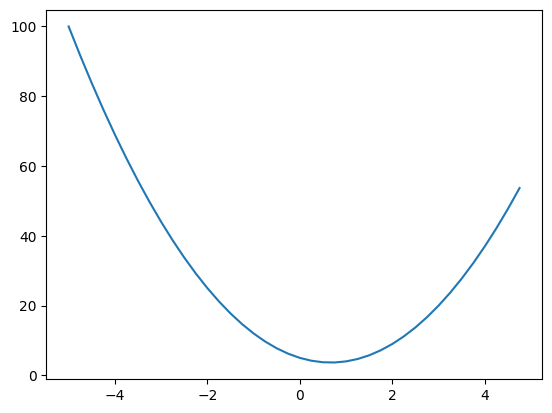

In [211]:
plt.plot(xs,ys)

In [212]:
h = 0.000000000001
x = 2/3
f(x)
(f(x+h) -f(x))/h

-0.0004440892098500626

In [213]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [214]:
#56.00

In [342]:
class Value():
    def __init__(self, data, _childeren=(),_op='', label=''):
        self.data = data
        self._prev=set(_childeren)
        self._backward=lambda: None
        self._op=_op
        self.label=label
        self.grad=0.0
    def __repr__(self):        
        return f"Value(data={self.data}, label={self.label})"
    def __add__(self, other):
        other=other if isinstance(other, Value) else Value(other)
        out= Value(self.data + other.data,(self,other),'+')
        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad 
        out._backward=_backward
        return out
    def __radd__(self, other):
        return self + other
    def __mul__(self, other):
        other=other if isinstance(other, Value) else Value(other)
        out= Value(self.data * other.data,(self,other),'*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    def __rmul__(self, other):
        return self * other
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out
    def __neg__(self):
       return self * -1
    def __sub__(self, other):
        other=other if isinstance(other, Value) else Value(other)
        return self + (-other)
    def tanh(self):
        x = self.data
        t = (math.exp(x) - math.exp(-x)) / (math.exp(x) + math.exp(-x))
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [266]:
a=Value(2.0, label='a')
b=Value(-3.0, label='b')
c=Value(10.0, label='c')
e=a*b 
e.label='e'
d=e+c
d.label='d'
f=Value(-2.0, label='f')
L=d*f
L.label='L'
print(L)

Value(data=-8.0, label=L)


In [217]:
L.grad=1.0

In [218]:
f.grad=4.0
d.grad=-2.0

In [219]:
c.grad=-2.0
e.grad=-2.0

In [220]:
a.grad=-2.0*-3.0
b.grad=-2.0*2.0

In [221]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [222]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

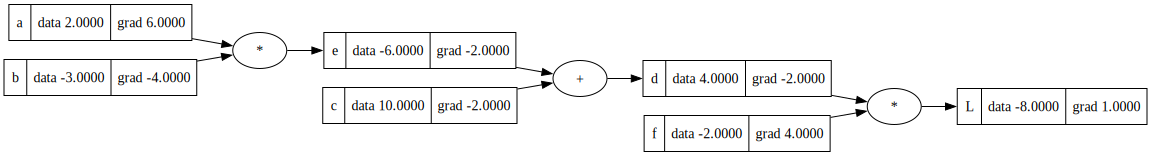

In [223]:
draw_dot(L)

In [224]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o=n.tanh()


In [267]:
o.backward()

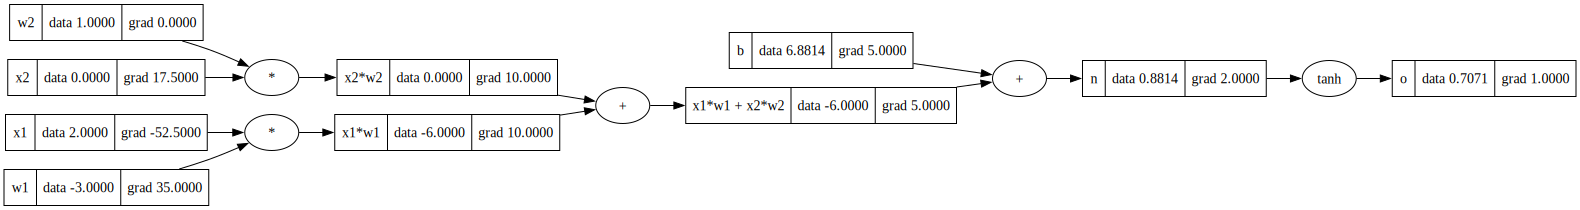

In [268]:
draw_dot(o)

In [227]:
o.grad=1.0
n.grad=(1-o.data**2)

n.grad=1-o.data**2

In [228]:
b.grad=n.grad
x1w1x2w2.grad=n.grad

In [229]:
x1w1.grad=x1w1x2w2.grad
x2w2.grad=x1w1x2w2.grad

In [230]:
x2.grad=x2w2.grad*w2.data
w2.grad=x2w2.grad*x2.data
x1.grad=x1w1.grad*w1.data
w1.grad=x1w1.grad*x1.data

In [231]:
o.grad=1.0
o._backward()

In [232]:
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()    

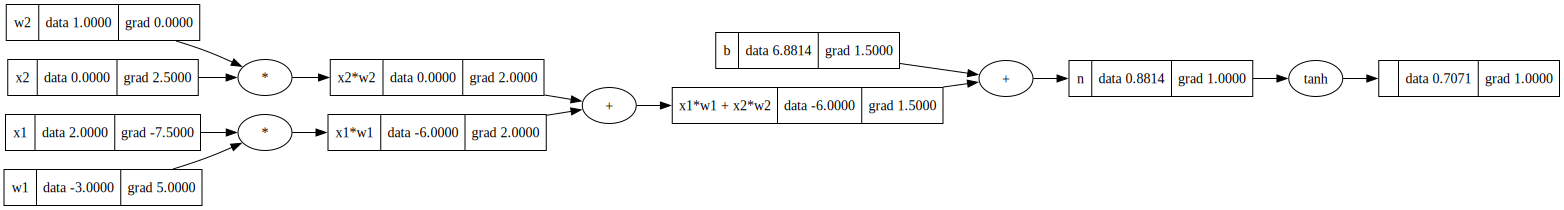

In [233]:
draw_dot(o)

In [234]:
 o = n.tanh(); o.label = 'o'

In [235]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543, label=b),
 Value(data=-3.0, label=w1),
 Value(data=2.0, label=x1),
 Value(data=-6.0, label=x1*w1),
 Value(data=1.0, label=w2),
 Value(data=0.0, label=x2),
 Value(data=0.0, label=x2*w2),
 Value(data=-6.0, label=x1*w1 + x2*w2),
 Value(data=0.8813735870195432, label=n),
 Value(data=0.7071067811865477, label=o)]

In [236]:
o.grad = 1.0

In [269]:
for node in reversed(topo):
    node._backward()

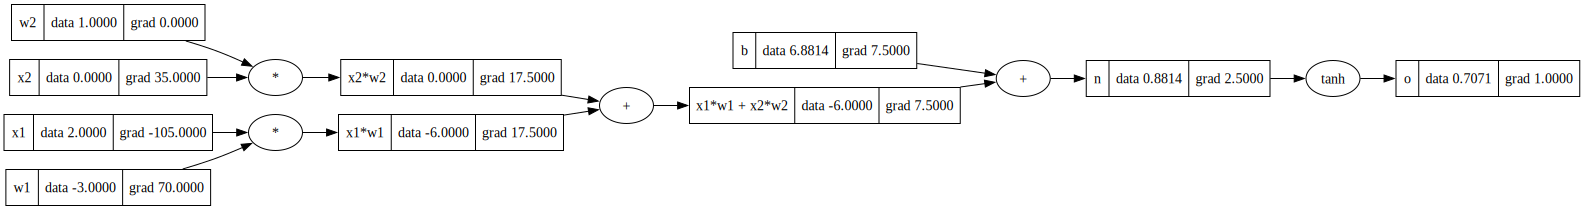

In [270]:
draw_dot(o)

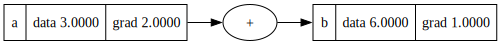

In [271]:
a=Value(3.0, label='a')
b=a+a ; b.label='b'
b.backward()
draw_dot(b)

In [343]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0.0)
    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]

In [308]:
x=[2.0, 3.0]
n = Neuron(2)
n(x).backward()

In [309]:
n.w[0].data, n.w[0].grad

(0.15075736478720003, 0.24825019178471952)

In [344]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

In [311]:
nl = Layer(2,3)
nl(x)

[Value(data=0.8783005368529291, label=),
 Value(data=0.16562349116281352, label=),
 Value(data=-0.41824498878167393, label=)]

In [345]:
class Mlp:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

In [314]:
x=[2.0, 3.0]
n=Layer(2,3)
n=n(x)

In [ ]:
n

In [315]:
xs=[2.0, 3.0, -1.0]
   

ys=1.0

In [346]:
xs=[
    [2.0, 5.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0 ],
    [1.0, 1.0, -1.0],
]
ys=[1.0, -1.0, -1.0, 1.0]

In [348]:
j=Mlp(3, [4,4,1])

In [354]:
j(xs[0]).backward()

In [355]:
j.layers[0].neurons[0].w[0].data, j.layers[0].neurons[0].w[0].grad

(0.5274062054210165, -2.747873027772242)

In [357]:
for k in range(10):
    ys_pred=[j(x) for x in xs]
    loss=sum((ypred-y)**2 for ypred, y in zip(ys_pred, ys))
    for p in j.parameters():
        p.grad=0.0
    loss.backward()
    for p in j.parameters():
        p.data += -0.01*p.grad
       
    print(k, loss.data)
        
  
        
    

0 7.123426259890349
1 6.924713600573325
2 6.664432294165381
3 6.305966976894847
4 5.795306114569851
5 5.0728698146692945
6 4.153566404342376
7 3.2620885222159197
8 2.653150974897624
9 2.281568467317998


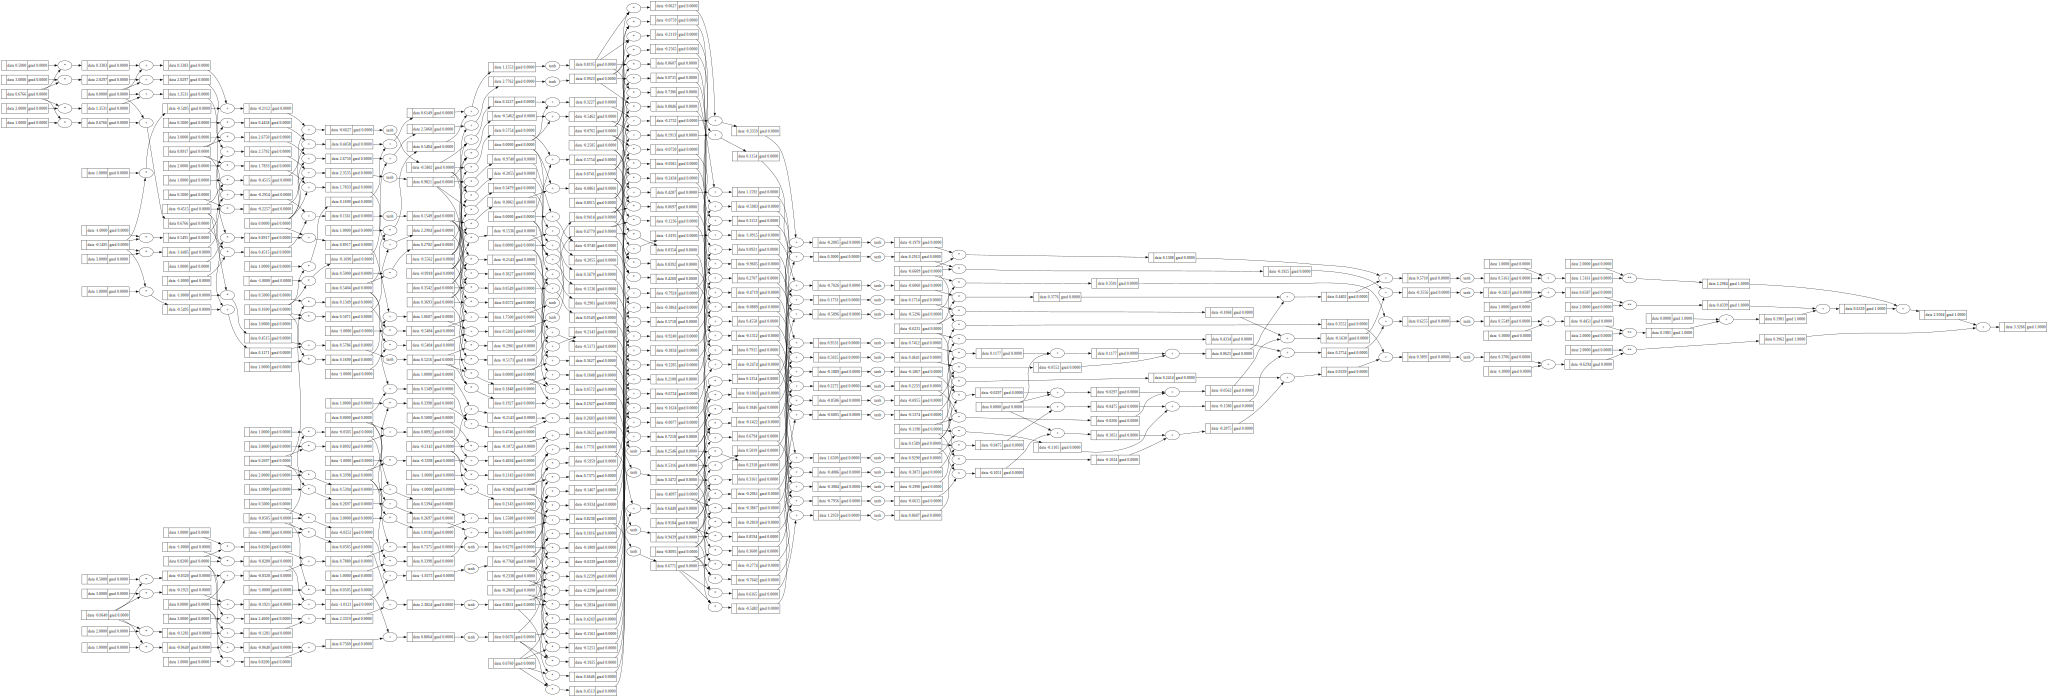

In [252]:
draw_dot(loss)

In [253]:
m.parameters()

[Value(data=0.6765705539751632, label=),
 Value(data=-0.549501871842264, label=),
 Value(data=-0.4514895307568869, label=),
 Value(data=0.0, label=),
 Value(data=-0.06402844893238324, label=),
 Value(data=0.8199987635360828, label=),
 Value(data=-0.05047334348755883, label=),
 Value(data=0.0, label=),
 Value(data=0.8916744324404631, label=),
 Value(data=0.16903370650231753, label=),
 Value(data=0.5404379732305558, label=),
 Value(data=0.0, label=),
 Value(data=0.26971997612091614, label=),
 Value(data=0.339786211024349, label=),
 Value(data=-0.2143151344562806, label=),
 Value(data=0.0, label=),
 Value(data=-0.9918012838183092, label=),
 Value(data=-0.2337964039188083, label=),
 Value(data=0.8914571168023229, label=),
 Value(data=-0.8095272442877786, label=),
 Value(data=0.0, label=),
 Value(data=0.3693438231133854, label=),
 Value(data=0.6759965319072587, label=),
 Value(data=0.07406182539469541, label=),
 Value(data=0.9104291349503506, label=),
 Value(data=0.0, label=),
 Value(data=0

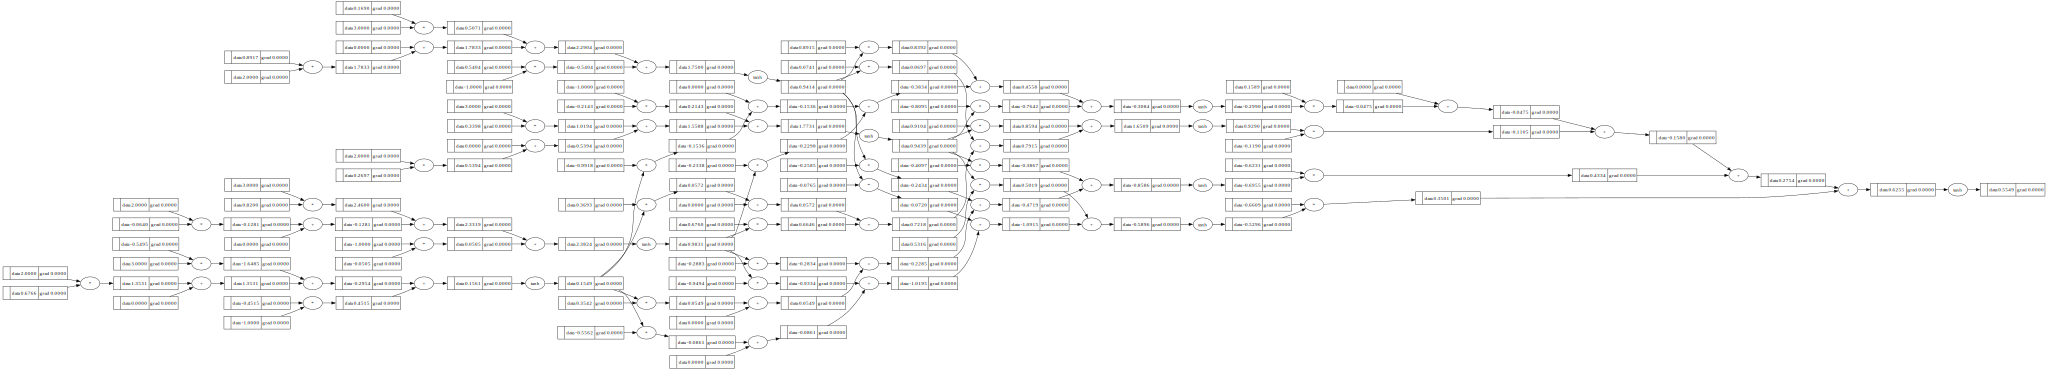

In [254]:
draw_dot(m(x))